Date                   0
Time                   0
CO(GT)                 0
NOx(GT)                0
NO2(GT)                0
O3(GT)                 0
SO2(GT)                0
PM2.5                  0
PM10                   0
Temperature            0
Humidity               0
Pressure               0
WindSpeed              0
WindDirection          0
CO_NOx_Ratio           0
NOx_NO2_Ratio          0
Temp_Humidity_Index    0
AirQualityIndex        0
CO_MA3                 0
NO2_MA3                0
O3_MA3                 0
DayOfWeek              0
Hour                   0
dtype: int64
                                Date       CO(GT)      NOx(GT)      NO2(GT)  \
count                           4000  4000.000000  4000.000000  4000.000000   
mean   2024-03-23 20:00:57.600000256     5.025385   148.126633   100.213189   
min              2024-01-01 00:00:00     0.100115     1.009185     1.010513   
25%              2024-02-11 00:00:00     2.514242    73.636615    51.326622   
50%              

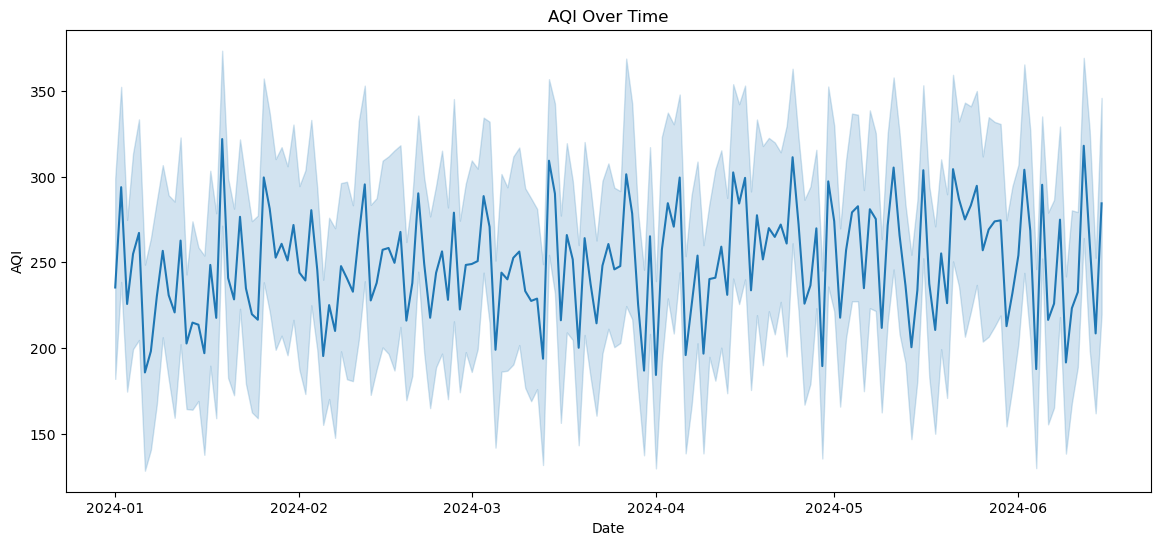

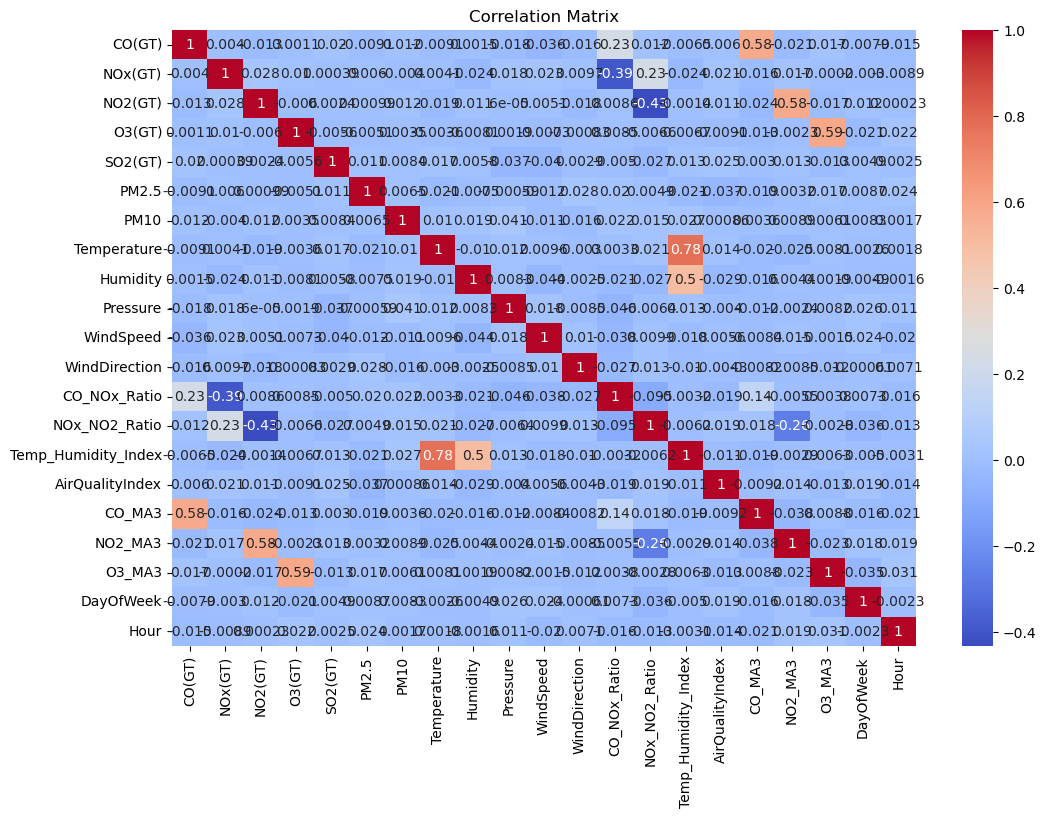

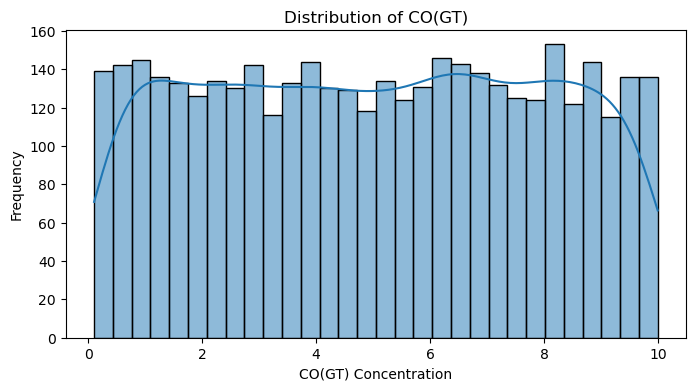

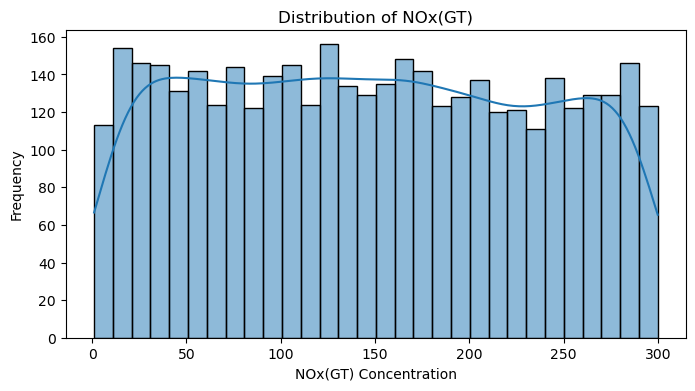

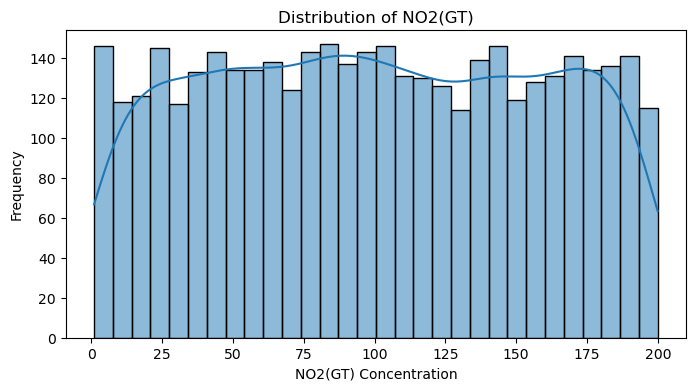

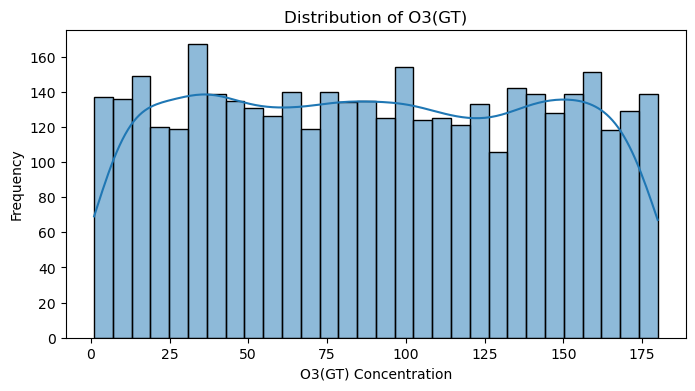

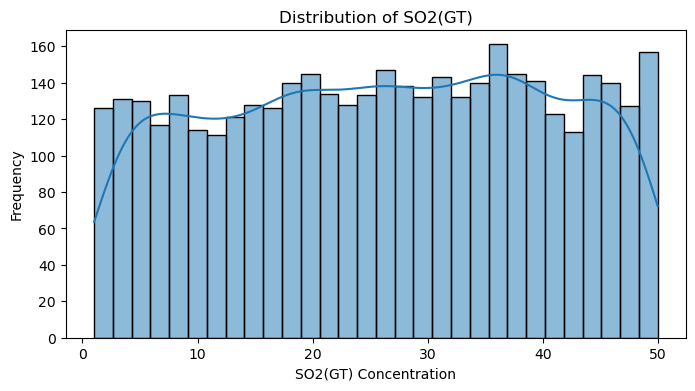

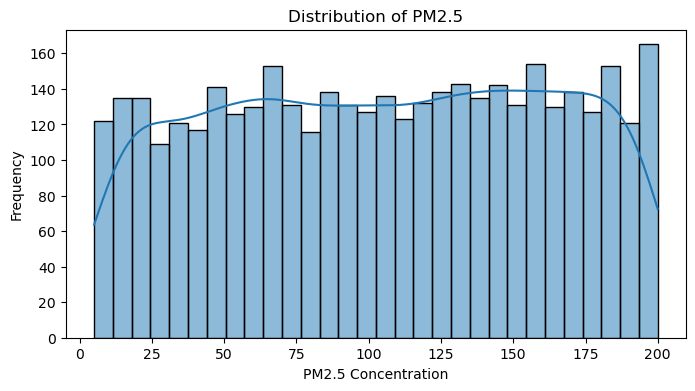

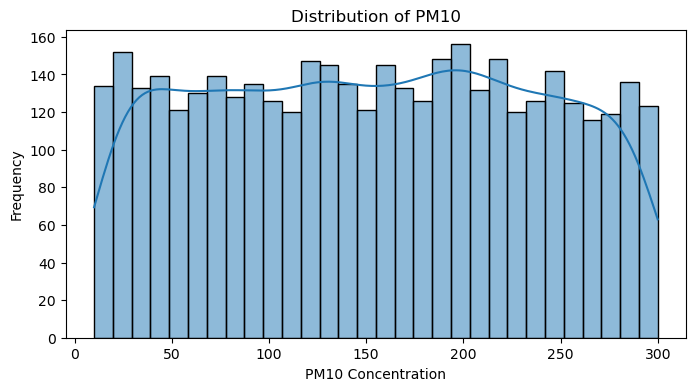

AirQualityIndex        1.000000
SO2(GT)                0.024626
NOx(GT)                0.020691
DayOfWeek              0.019484
NOx_NO2_Ratio          0.018962
Temperature            0.014175
NO2_MA3                0.013948
NO2(GT)                0.011104
CO(GT)                 0.005958
WindSpeed              0.005551
PM10                   0.000862
Pressure              -0.003967
WindDirection         -0.004324
O3(GT)                -0.009054
CO_MA3                -0.009203
Temp_Humidity_Index   -0.011309
O3_MA3                -0.012889
Hour                  -0.014327
CO_NOx_Ratio          -0.019032
Humidity              -0.028728
PM2.5                 -0.037478
Name: AirQualityIndex, dtype: float64


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('AirQualityData.csv')  # Replace with your actual file path


# Check for missing values
print(df.isnull().sum())

# Convert 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])
#summary Statistics
print(df.describe())

df.columns = df.columns.str.strip()

# Optional: Drop rows where AQI is missing
df = df.dropna(subset=['AirQualityIndex'])

# Plot AQI over time
plt.figure(figsize=(14, 6))
sns.lineplot(x='Date', y='AirQualityIndex', data=df)
plt.title('AQI Over Time')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.show()


# Compute correlation matrix
corr_matrix = df.select_dtypes(include=['number']).corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


pollutants = ['CO(GT)', 'NOx(GT)', 'NO2(GT)', 'O3(GT)', 'SO2(GT)', 'PM2.5', 'PM10']

for pollutant in pollutants:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[pollutant], bins=30, kde=True)
    plt.title(f'Distribution of {pollutant}')
    plt.xlabel(f'{pollutant} Concentration')
    plt.ylabel('Frequency')
    plt.show()
    


# Display most relevant correlations
print(corr_matrix['AirQualityIndex'].sort_values(ascending=False))

In [3]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Define features and target
features = df[['PM2.5', 'PM10', 'NO2(GT)', 'SO2(GT)', 'CO(GT)','O3(GT)']].dropna()
target = df.loc[features.index, 'AirQualityIndex']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Train model
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Feature importance
importances = model.feature_importances_
for col, imp in zip(features.columns, importances):
    print(f"{col}: {imp:.3f}")


PM2.5: 0.169
PM10: 0.173
NO2(GT): 0.163
SO2(GT): 0.165
CO(GT): 0.168
O3(GT): 0.163


In [5]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

kmeans = KMeans(n_clusters=3, n_init=10, random_state=42) 
# Select relevant features
features = df[['PM2.5', 'PM10', 'NO2(GT)', 'SO2(GT)', 'CO(GT)','O3(GT)']].dropna()

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# View a few results
print(df[['PM2.5', 'PM10', 'NO2(GT)', 'SO2(GT)', 'CO(GT)','O3(GT)','Cluster']].head())



C:\Users\19134\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


        PM2.5        PM10     NO2(GT)    SO2(GT)    CO(GT)      O3(GT)  \
0  147.349671  208.803124  144.333317   1.215679  3.807947  118.120832   
1   40.979839  145.595579  137.769318   1.016178  9.512072   15.325830   
2   72.594740   26.155000   20.055086  24.140910  7.346740   44.377036   
3  134.339724  276.367944  184.591909   2.435392  6.026719  139.488603   
4   99.007422  294.295449  114.125968  48.752095  1.644585   95.634768   

   Cluster  
0        2  
1        2  
2        2  
3        2  
4        1  
